# Day 1 — Dataset Understanding

This notebook inspects UCI #361 Twin Gas Sensor Arrays and prepares methane-only data for calibration-transfer experiments.


In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path('..').resolve()))
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DATA_RAW, FIGURES
from src.parse_twin_gas import list_data_files, summarize_files, read_trial, add_time_column
FIGURES.mkdir(exist_ok=True, parents=True)


## 1. Locate raw files
Place the downloaded UCI #361 archive contents under `data/raw/`.


In [2]:
files = list_data_files(DATA_RAW)
summary = summarize_files(files)
summary.head(), summary.shape


(                                                path            filename  \
 0  C:\Users\hg\PycharmProjects\mox_calibration_tr...  B1_GCO_F010_R1.txt   
 1  C:\Users\hg\PycharmProjects\mox_calibration_tr...  B1_GCO_F010_R2.txt   
 2  C:\Users\hg\PycharmProjects\mox_calibration_tr...  B1_GCO_F010_R3.txt   
 3  C:\Users\hg\PycharmProjects\mox_calibration_tr...  B1_GCO_F010_R4.txt   
 4  C:\Users\hg\PycharmProjects\mox_calibration_tr...  B1_GCO_F020_R1.txt   
 
   board              gas  concentration_ppm   day   size_mb  
 0    B1  carbon_monoxide                1.0  None  3.869000  
 1    B1  carbon_monoxide                1.0  None  4.376861  
 2    B1  carbon_monoxide                1.0  None  4.376204  
 3    B1  carbon_monoxide                1.0  None  4.277581  
 4    B1  carbon_monoxide                1.0  None  4.379854  ,
 (640, 7))

In [3]:
summary.to_csv('../results/day1_file_inventory.csv', index=False)
summary.groupby(['board','gas'], dropna=False).size()


board  gas            
B1     carbon_monoxide     40
       NaN                120
B2     carbon_monoxide     40
       NaN                120
B3     carbon_monoxide     40
       NaN                120
B4     carbon_monoxide     20
       NaN                 60
B5     carbon_monoxide     20
       NaN                 60
dtype: int64

## 2. Inspect one file
Verify delimiter, number of columns, whether signals are resistance or conductance, and whether time is explicit.


In [4]:
example = files[0]
df0 = read_trial(example)
df0.shape, df0.head()


((53000, 9),
       0      1      2     3     4      5      6      7     8
 0  0.00  38.91  18.64  21.6  5.56  72.63  45.67  55.54  7.00
 1  0.01  38.91  18.66  21.6  5.56  72.85  45.67  55.40  6.99
 2  0.02  38.91  18.66  21.6  5.56  72.85  45.67  55.54  7.00
 3  0.03  38.99  18.66  21.6  5.56  72.85  45.77  55.40  6.99
 4  0.04  38.99  18.66  21.6  5.57  72.85  45.87  55.54  7.00)

## 3. Plot example methane response curves
Adjust sensor column names after confirming file structure.


Saved PNG to: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day1\day1_example_response_curve_corrected.png
Saved PDF to: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day1\day1_example_response_curve_corrected.pdf


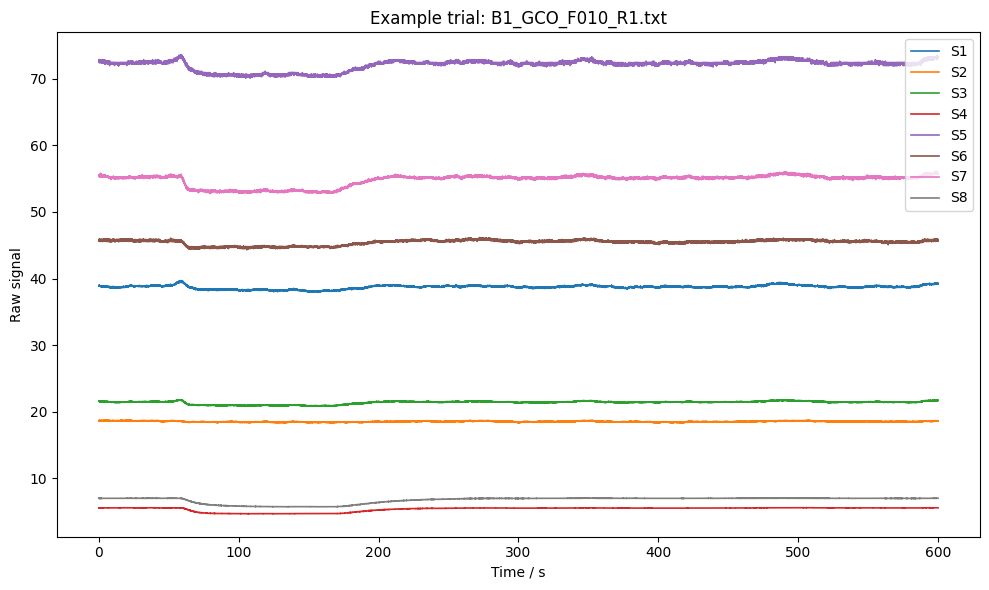

In [8]:
# Placeholder: update after inspection
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Always resolve paths from notebook location
PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "figures" / "day1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Pick example file
example_file = RAW_DIR / "B1_GCO_F010_R1.txt"

# Read file
df = pd.read_csv(
    example_file,
    sep=None,
    engine="python",
    header=None
)

# Correct structure:
# column 0 = time
# columns 1-8 = sensor signals
time = df.iloc[:, 0]
sensor_data = df.iloc[:, 1:9]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(sensor_data.shape[1]):
    ax.plot(time, sensor_data.iloc[:, i], label=f"S{i+1}", linewidth=1.2)

ax.set_xlabel("Time / s")
ax.set_ylabel("Raw signal")
ax.set_title(f"Example trial: {example_file.name}")
ax.legend()

fig.tight_layout()

# Save figures, overwrite if already exists
png_path = FIG_DIR / "day1_example_response_curve_corrected.png"
pdf_path = FIG_DIR / "day1_example_response_curve_corrected.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

print(f"Saved PNG to: {png_path}")
print(f"Saved PDF to: {pdf_path}")

plt.show()

## Day 1 observations
- Fill in after inspecting raw archive.
- Confirm filename metadata parsing.
- Confirm baseline/exposure/recovery timing before feature extraction.


In [6]:
import pandas as pd
from pathlib import Path

# 找一个原始 txt 文件
example_file = list(Path("../data/raw").rglob("*.txt"))[0]

print("Example file:")
print(example_file)

# 自动尝试解析分隔符
df = pd.read_csv(
    example_file,
    sep=None,
    engine="python",
    header=None
)

print("\nShape:")
print(df.shape)

print("\nFirst 10 rows:")
print(df.head(10))

Example file:
..\data\raw\B1_GCO_F010_R1.txt

Shape:
(53000, 9)

First 10 rows:
      0      1      2     3     4      5      6      7     8
0  0.00  38.91  18.64  21.6  5.56  72.63  45.67  55.54  7.00
1  0.01  38.91  18.66  21.6  5.56  72.85  45.67  55.40  6.99
2  0.02  38.91  18.66  21.6  5.56  72.85  45.67  55.54  7.00
3  0.03  38.99  18.66  21.6  5.56  72.85  45.77  55.40  6.99
4  0.04  38.99  18.66  21.6  5.57  72.85  45.87  55.54  7.00
5  0.05  38.91  18.66  21.6  5.56  72.85  45.87  55.54  7.00
6  0.06  38.91  18.66  21.6  5.57  72.85  45.77  55.54  7.00
7  0.07  38.91  18.66  21.6  5.56  72.85  45.87  55.54  7.00
8  0.08  38.99  18.72  21.6  5.56  72.63  45.87  55.54  6.99
9  0.09  38.99  18.66  21.6  5.56  72.85  45.77  55.54  7.00


In [9]:
import pandas as pd
from pathlib import Path

RAW_DIR = Path("../data/raw")

all_files = sorted(RAW_DIR.rglob("*.txt"))

print(f"Found {len(all_files)} txt files")

records = []

for file in all_files:

    name = file.stem
    parts = name.split("_")

    # Example:
    # B1_GCO_F010_R1

    try:
        board = parts[0]
        gas = parts[1]
        concentration = parts[2]
        replicate = parts[3]

        records.append({
            "file": str(file),
            "filename": name,
            "board": board,
            "gas": gas,
            "concentration": concentration,
            "replicate": replicate
        })

    except Exception as e:
        print(f"Failed parsing: {name}")
        print(e)

metadata_df = pd.DataFrame(records)

print(metadata_df.head())

print("\nBoards:")
print(metadata_df["board"].value_counts())

print("\nGases:")
print(metadata_df["gas"].value_counts())

print("\nConcentrations:")
print(metadata_df["concentration"].value_counts())

print("\nReplicates:")
print(metadata_df["replicate"].value_counts())

Found 640 txt files
                             file        filename board  gas concentration  \
0  ..\data\raw\B1_GCO_F010_R1.txt  B1_GCO_F010_R1    B1  GCO          F010   
1  ..\data\raw\B1_GCO_F010_R2.txt  B1_GCO_F010_R2    B1  GCO          F010   
2  ..\data\raw\B1_GCO_F010_R3.txt  B1_GCO_F010_R3    B1  GCO          F010   
3  ..\data\raw\B1_GCO_F010_R4.txt  B1_GCO_F010_R4    B1  GCO          F010   
4  ..\data\raw\B1_GCO_F020_R1.txt  B1_GCO_F020_R1    B1  GCO          F020   

  replicate  
0        R1  
1        R2  
2        R3  
3        R4  
4        R1  

Boards:
board
B1    160
B2    160
B3    160
B4     80
B5     80
Name: count, dtype: int64

Gases:
gas
GCO    160
GEa    160
GEy    160
GMe    160
Name: count, dtype: int64

Concentrations:
concentration
F010    64
F020    64
F030    64
F040    64
F050    64
F060    64
F070    64
F080    64
F090    64
F100    64
Name: count, dtype: int64

Replicates:
replicate
R1    200
R2    200
R3    120
R4    120
Name: count, dtype: int6

Saved figure to: C:\Users\hg\PycharmProjects\mox_calibration_transfer\figures\day1\methane_board_comparison_sensor1.png


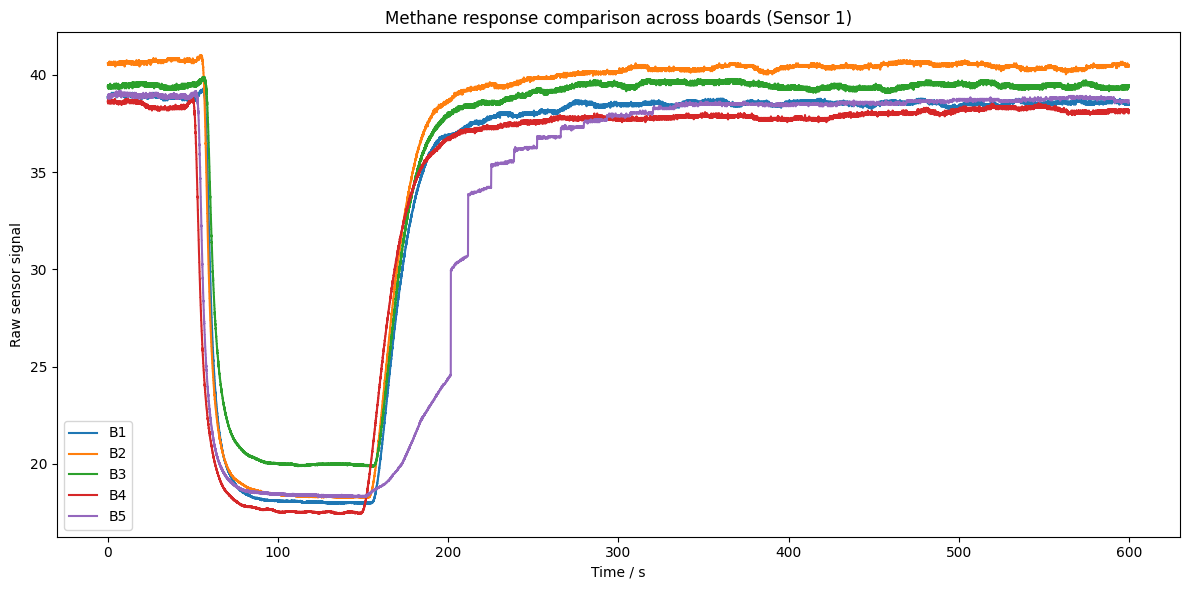

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "figures" / "day1"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------
# Select methane files at same concentration/replicate
# ---------------------------------------------------

selected = [
    "B1_GMe_F050_R1.txt",
    "B2_GMe_F050_R1.txt",
    "B3_GMe_F050_R1.txt",
    "B4_GMe_F050_R1.txt",
    "B5_GMe_F050_R1.txt",
]

sensor_idx = 0  # compare Sensor 1 first

plt.figure(figsize=(12, 6))

for fname in selected:

    file_path = RAW_DIR / fname

    df = pd.read_csv(
        file_path,
        sep=None,
        engine="python",
        header=None
    )

    time = df.iloc[:, 0]

    # sensor columns = 1~8
    sensor_signal = df.iloc[:, sensor_idx + 1]

    board = fname.split("_")[0]

    plt.plot(
        time,
        sensor_signal,
        label=board,
        linewidth=1.5
    )

plt.xlabel("Time / s")
plt.ylabel("Raw sensor signal")
plt.title("Methane response comparison across boards (Sensor 1)")
plt.legend()

plt.tight_layout()

save_path = FIG_DIR / "methane_board_comparison_sensor1.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {save_path}")

plt.show()

In [12]:
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

observations = """
# Day 1 Observations

## Dataset structure

- Total files: 640
- Boards: B1–B5
- Gases:
  - GCO = Carbon Monoxide
  - GEa = Ethanol
  - GEy = Ethylene
  - GMe = Methane

- Each file contains:
  - column 0 = time
  - columns 1–8 = MOx sensor channels

- Sampling interval:
  - 0.01 s

- Approximate experiment duration:
  - 530 s

## Methane response observations

### Board-to-board variation

- Strong baseline offsets exist across boards.
- Response magnitude differs between boards.
- B5 shows noticeably slower recovery behavior.

### Shared temporal structure

Despite amplitude differences, all boards show:

- similar response timing
- similar exposure/recovery phases
- similar dynamic response shape

This suggests that physics-informed temporal features may transfer better than raw signals.

### Transfer learning implications

Raw signal transfer is expected to perform poorly because:

- sensor baselines vary
- absolute amplitudes vary

However, normalized or physically meaningful features may improve transferability.

## Initial conclusion

The dataset appears suitable for:

- calibration transfer
- few-shot adaptation
- physics-informed feature engineering
- sensor-to-sensor generalization studies
"""

output_path = RESULTS_DIR / "day1_observations.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(observations)

print(f"Saved observations to: {output_path}")

Saved observations to: ..\results\day1_observations.md
